# 02 · Reading out a qutrit: IQ discrimination and readout-error mitigation

Every experiment in this shop ends with a resonator measurement that returns one complex number (I, Q) per shot.
A qubit experiment only needs a line between two clouds; a qutrit needs three clouds and a way to deal with the
fact that |2⟩ is read out worse than |0⟩ and |1⟩. Three generations of discriminators were written:

| years | method | where |
|---|---|---|
| 2022–24 | linear discriminant analysis (scikit-learn) on the 3 calibration circuits, cvxopt / SLSQP readout mitigation | Qiskit-textbook style helpers, `utility.DataAnalysis` |
| 2025 | nearest cluster centre, centres chosen by eye, 3×3 confusion matrix | `characterization/discrim/discrim.ipynb` |
| 2025 | two circles of radius $r$ around the |0⟩ and |2⟩ centres fitted on a Rabi oscillation; everything else is |1⟩ | `rabi_script.ipynb`, `rabi_discrim.pkl` (now `data/pending_2025/rabi_discrim.json`) |

All three live in `pulseshop.readout`. This notebook trains them on the saved calibration shots and shows what the confusion matrices look like.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, json
import matplotlib.pyplot as plt
from pulseshop import readout, io, fitting
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. 2022 — `ibm_oslo` qubit 0, LDA

`QuantumExperiment/Hadamard/discr_data.csv` (25 Aug 2022, written by `Pulses/discr.ipynb`) holds 20 000 single shots for each of |0⟩, |1⟩ (IBM `x`) and |2⟩ (`x` then our
544 dt X12 pulse). These are the shots used for the qutrit Hadamard experiment of notebook 05.

LDA test accuracy: 0.9491
confusion matrix (rows = prepared |0>,|1>,|2>; columns = assigned):
 [[0.9306 0.0109 0.0586]
 [0.013  0.9624 0.0246]
 [0.0103 0.036  0.9537]]


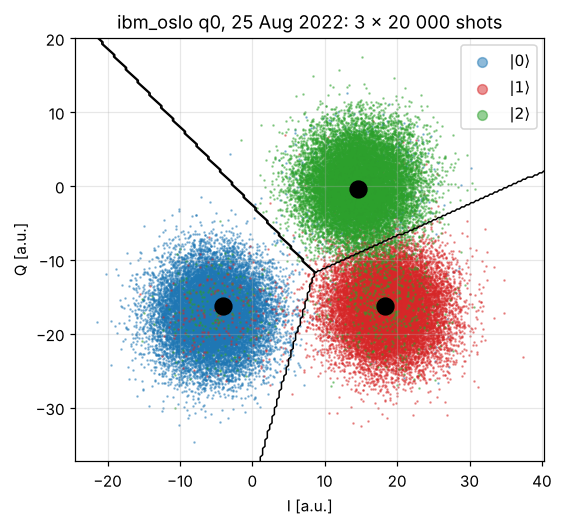

In [2]:
oslo = io.load_npy("lab_2022", "oslo_2022-08-25_discriminator_shots.npy")
lda = readout.LDADiscriminator(test_size=0.3, random_state=0).fit(oslo)
cm_oslo = readout.confusion_matrix(oslo, lda)
print("LDA test accuracy:", round(lda.score, 4))
print("confusion matrix (rows = prepared |0>,|1>,|2>; columns = assigned):\n", np.round(cm_oslo, 4))

fig, ax = plt.subplots(figsize=(5.5, 5))
readout.iq_012_plot(oslo, ax=ax, s=0.4, title="ibm_oslo q0, 25 Aug 2022: 3 x 20 000 shots")
lda.separatrix(ax=ax)
io.save_fig(fig, "02_oslo_2022_lda_iq_plane")

The 2022 notebooks reported an LDA accuracy of 0.949 on this data set, reproduced here; the |2⟩ cloud sits between the other two, which is what limits it.

## 2. 2024 — `ibm_brisbane` qubit 109, the post-selection trick

By mid-2024 the readout of qubit 109 was good enough to use a cheaper trick (`characterization/rabi12/qubit109/data.ipynb`):
take the reference clouds (`IQ_data_state{0,1,2}_single`), fit 2-D Gaussians and keep only shots inside 1.96σ. The clouds below are those references.

centres (I, Q): [[-43.   43.2]
 [ 41.4  40.3]
 [ 14.7  16.7]]
nearest-centre confusion matrix:
 [[0.9804 0.0157 0.0038]
 [0.0245 0.92   0.0555]
 [0.1962 0.1339 0.6699]]
LDA confusion matrix:
 [[0.9818 0.0163 0.0019]
 [0.0244 0.9354 0.0402]
 [0.197  0.1248 0.6782]]


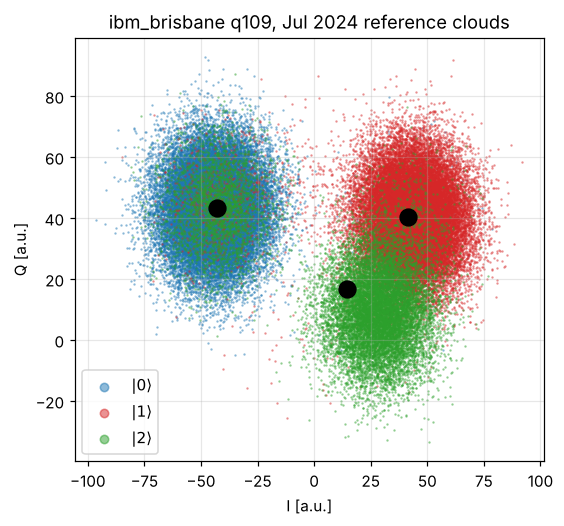

In [3]:
ref24 = [io.load_npy("shop_2024/characterization/rabi12/qubit109/data", f"IQ_data_state{k}_single.npy")[0] for k in range(3)]
cd24 = readout.CentroidDiscriminator.from_shots(ref24)
print("centres (I, Q):", np.round(cd24.centres, 1))
print("nearest-centre confusion matrix:\n", np.round(readout.confusion_matrix(ref24, cd24), 4))
lda24 = readout.LDADiscriminator(random_state=0).fit(ref24)
print("LDA confusion matrix:\n", np.round(readout.confusion_matrix(ref24, lda24), 4))
fig, ax = plt.subplots(figsize=(5.5, 5))
readout.iq_012_plot(ref24, ax=ax, s=0.3, title="ibm_brisbane q109, Jul 2024 reference clouds")
# note the |2> reference contains ~20 % of shots in the |0> cloud: the X12 preparation of July 2024 was not yet
# clean (this is the 'residual |2>' problem chased in rabi12/qubit109/script.ipynb with active reset).
io.save_fig(fig, "02_brisbane_q109_2024_reference_clouds")

## 3. 2025 — nearest-centre discriminator and the paper's confusion matrix

`characterization/discrim/discrim.ipynb` (31 Jan 2025) prepared each state in its own job with 10 000 shots and chose the centres
(−35, 30), (32, 32), (22, 6) by eye. The |2⟩ cloud now sits *below* |1⟩ rather than between |0⟩ and |1⟩ — the readout frequency and
amplitude had been tuned (`MeasurePulseOptimization.ipynb`, 2024) to separate it.

confusion matrix recomputed:
 [[0.977  0.0184 0.0046]
 [0.0186 0.8744 0.107 ]
 [0.0218 0.1448 0.8334]]
confusion matrix saved in the repo:
 [[0.9771 0.0184 0.0045]
 [0.0188 0.889  0.0922]
 [0.0218 0.1629 0.8153]]


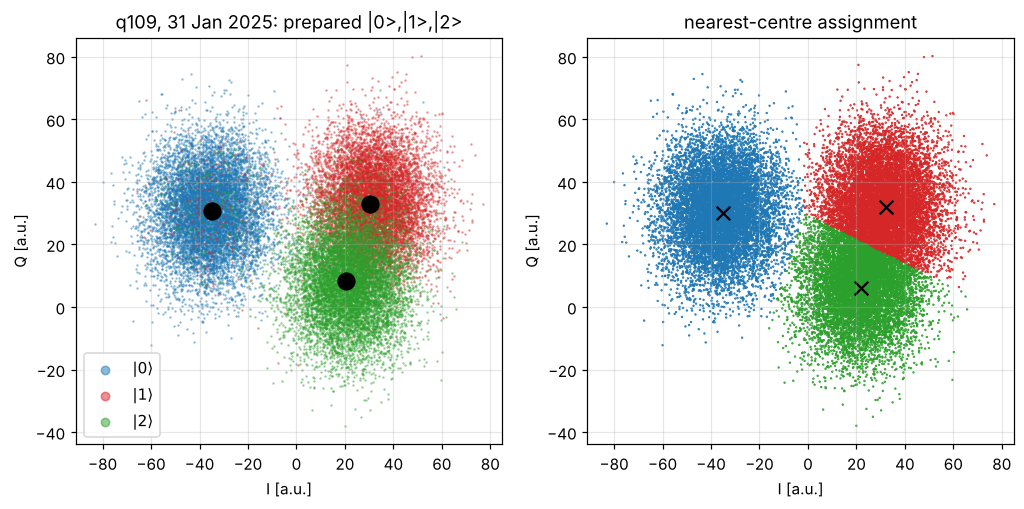

In [4]:
jobs = ["cy22fmycw2k0008jg8m0", "cy22fne6vek0008rbv8g", "cy22wdh9b62g008h80y0"]
shots25 = [io.load_job(f"pending_2025/characterization/discrim/data/{j}")[0][0] for j in jobs]
centres = io.load_npy("pending_2025", "central_clusters.npy")
cd25 = readout.CentroidDiscriminator(centres)
cm25 = readout.confusion_matrix(shots25, cd25)
print("confusion matrix recomputed:\n", np.round(cm25, 4))
print("confusion matrix saved in the repo:\n", io.load_npy("pending_2025", "confusion_matrix.npy"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
readout.iq_012_plot(shots25, ax=axes[0], s=0.3, title="q109, 31 Jan 2025: prepared |0>,|1>,|2>")
cols = np.array(["tab:blue", "tab:red", "tab:green"])
allshots = np.concatenate(shots25)
lab = cd25.predict(allshots)
axes[1].scatter(np.real(allshots), np.imag(allshots), s=0.3, c=cols[lab])
axes[1].scatter(centres[:, 0], centres[:, 1], c="k", s=80, marker="x")
axes[1].set(xlabel="I [a.u.]", ylabel="Q [a.u.]", title="nearest-centre assignment")
io.save_fig(fig, "02_brisbane_q109_2025_discriminator")

(The saved matrix was computed with the original notebook's radius-30 outlier rule, hence the small differences in rows 2 and 3.)

|2⟩ is misread as |1⟩ 10–16 % of the time. Only a small part of that is relaxation during the 1.4 µs readout ($T_1$ of |2⟩ ≈ 150 µs,
notebook 09); most of it is the overlap of the |1⟩ and |2⟩ clouds. Rather than fighting this, the paper experiments were designed so
that the quantity of interest is a population *contrast* and the confusion matrix is applied afterwards.

## 4. The paper's radius discriminator

For the rotation-error, APE, DRAPE and phase-advance runs a simpler rule was used (`rabi_discrim.pkl`): the two Rabi
extremes of the 1–2 oscillation give the |0⟩ and |2⟩ cluster centres, $r$ = half their distance, and a shot is |0⟩ (|2⟩) when
inside the |0⟩ (|2⟩) circle; shots outside both circles are |1⟩ unless they lie left of |0⟩ (Re < 0 → |0⟩) or below |2⟩ (Im < 0 → |2⟩).

centres (-34.688777923583984+33.24757385253906j) (22.61384391784668+8.244571685791016j) radius 31.26
radius-rule confusion matrix on the Jan 2025 calibration shots:
 [[0.9776 0.0088 0.0136]
 [0.02   0.4111 0.5689]
 [0.0284 0.0141 0.9575]]


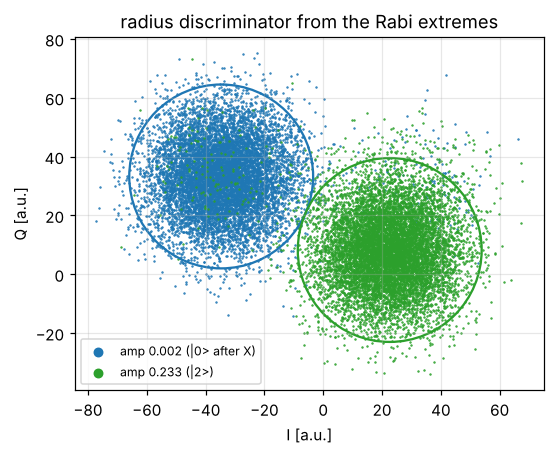

In [5]:
rd = io.load_json("pending_2025", "rabi_discrim.json")
radius = readout.RadiusDiscriminator(complex(rd["cluster_0_mean"]["re"], rd["cluster_0_mean"]["im"]),
                                     complex(rd["cluster_2_mean"]["re"], rd["cluster_2_mean"]["im"]), rd["radius_fit"])
print("centres", radius.c0, radius.c2, "radius", round(radius.radius, 2))
print("radius-rule confusion matrix on the Jan 2025 calibration shots:\n", np.round(readout.confusion_matrix(shots25, radius), 4))
# The |1> row is poor on purpose: this rule was built for sequences that end with an X pulse, so that the populations of
# interest sit in |0> and |2> and |1> is only the leftover. The |1> calibration cloud of 12 Jan lies inside the |2> circle
# of the 26 Jan Rabi clouds (the readout drifted between the two dates).

# how the centres were obtained: the Rabi oscillation of notebook 01, shots at its minimum and maximum
iq, prm = io.load_job("pending_2025/characterization/rabi/data/cyb4se57v8tg008fxxeg")
amps = np.linspace(prm["infimum"], prm["supremum"], prm["num_points"])
i_min, i_max = np.argmin(np.real(iq.mean(axis=1))), np.argmax(np.real(iq.mean(axis=1)))
fig, ax = plt.subplots(figsize=(5.5, 5))
for i, c, lab in [(i_min, "tab:blue", f"amp {amps[i_min]:.3f} (|0> after X)"), (i_max, "tab:green", f"amp {amps[i_max]:.3f} (|2>)")]:
    ax.scatter(np.real(iq[i]), np.imag(iq[i]), s=0.3, c=c, label=lab)
for c, col in [(radius.c0, "tab:blue"), (radius.c2, "tab:green")]:
    ax.add_patch(plt.Circle((c.real, c.imag), radius.radius, fill=False, color=col, lw=1.5))
ax.set(xlabel="I [a.u.]", ylabel="Q [a.u.]", title="radius discriminator from the Rabi extremes", aspect="equal")
ax.legend(markerscale=10, fontsize=8)
io.save_fig(fig, "02_radius_discriminator")

## 5. Readout-error mitigation

With a confusion matrix $C$ (row $i$ = what is measured when |i⟩ is prepared) the measured populations are $p = C^T x$.
Inverting $C$ amplifies noise and gives negative populations, so from Oct 2022 onwards the shop solved the constrained
least-squares problem $\min\|C^T x - p\|$ with $x \ge 0$, $\sum x = 1$ (cvxopt QP in the textbook-style notebooks, SLSQP in `utility.py`).
(Historical note: the 2022–24 QP helper used $C$ instead of $C^T$; with these nearly symmetric matrices the effect is at the percent level. `pulseshop` uses $C^T$.)

In [6]:
true = np.array([0.1, 0.3, 0.6])
measured = cm25.T @ true
print("true      ", true)
print("measured  ", np.round(measured, 4))
print("inverse   ", np.round(np.linalg.inv(cm25.T) @ measured, 4))
print("QP        ", np.round(readout.mitigated_population(measured, cm25), 4))
print("SLSQP     ", np.round(readout.data_mitigator(measured, cm25), 4))
# with shot noise: 5000 shots
rng = np.random.default_rng(1)
noisy = rng.multinomial(5000, measured) / 5000
print("noisy QP  ", np.round(readout.mitigated_population(noisy, cm25), 4), " inverse", np.round(np.linalg.inv(cm25.T) @ noisy, 4))

true       [0.1 0.3 0.6]
measured   [0.1164 0.351  0.5326]
inverse    [0.1 0.3 0.6]
QP         [0.1 0.3 0.6]
SLSQP      [0.1001 0.3004 0.5995]
noisy QP   [0.0977 0.2864 0.6159]  inverse [0.0977 0.2864 0.6159]


## 6. The historical `DataAnalysis` object

From Nov 2023 every acquisition notebook did `ut.DataAnalysis(job, ...)` → `retrieve_data` → `build_discrim` → `count_pop` → `error_mitiq`.
The offline re-implementation takes the saved IQ arrays (calibration circuits first). Example on a 2024 rotation-error run
whose first three circuits are the calibration circuits:

LDA score 0.885 | confusion diag [0.974 0.878 0.794] | experiment circuits: (21, 3)


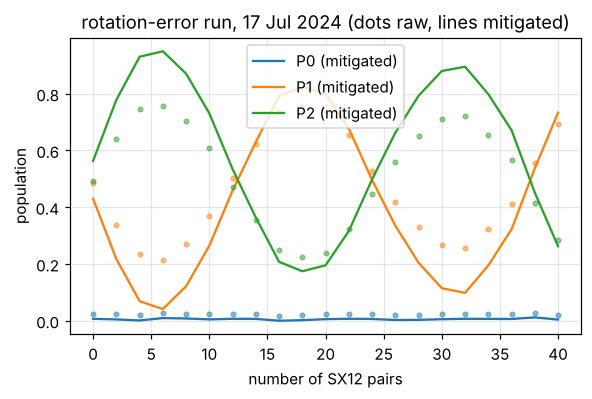

In [7]:
iq_re = io.load_npy("shop_2024/calibrator/rotation_error/qubit109/data/dur48", "round13_17jul24_afterDRAG.npy")
da = readout.DataAnalysis(iq_re)
pops = da.run()
print("LDA score", round(da.score_012, 3), "| confusion diag", np.round(np.diag(da.confusion_mat), 3), "| experiment circuits:", pops.shape)
fig, ax = plt.subplots(figsize=(6, 3.5))
N = 2 * np.arange(len(pops))
for k in range(3):
    ax.plot(N, da.raw_counted[3:, k], ".", color=f"C{k}", alpha=0.5)
    ax.plot(N, pops[:, k], "-", color=f"C{k}", label=f"P{k} (mitigated)")
ax.set(xlabel="number of SX12 pairs", ylabel="population", title="rotation-error run, 17 Jul 2024 (dots raw, lines mitigated)")
ax.legend()
io.save_fig(fig, "02_dataanalysis_example")

Notebook 04 fits this kind of curve. The take-away of this notebook: a qutrit readout on these devices is 80–98 % correct per
state (|0⟩ best, |2⟩ worst); the |2⟩→|1⟩ confusion is mostly cloud overlap, and every population quoted in the later notebooks is
mitigated with the matrix of the day.